In [69]:
# Import necessary libraries
# To download historical stock data
import numpy as np
import yfinance as yf
# For data manipulation
import pandas as pd
import seaborn as sns
# For OLS regression modeling
import statsmodels.api as sm
# For data visualization
import matplotlib.pyplot as plt
from scipy.stats import zscore


[*********************100%***********************]  2 of 2 completed

Correlation B/w X and Y is 0.7240814463392641


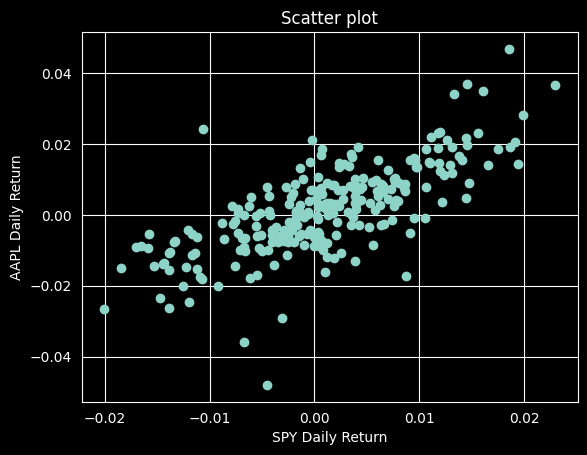

In [70]:
# Download daily close prices for AAPL and SPY for the last 1 year
data = yf.download(['AAPL', 'SPY'], start='2023-01-01', end='2024-01-01',auto_adjust=True)['Close']

# Drop rows with missing values (if any)
data = data.dropna()

# Calculate daily returns for AAPL and SPY
returns = data.pct_change().dropna()

# Define the dependent variable (Y) as AAPL returns
y = returns['AAPL']

# Define the independent variable (X) as SPY returns
x = returns['SPY']

# Plot x and y
plt.scatter(x,y)
plt.xlabel("SPY Daily Return")
plt.ylabel("AAPL Daily Return")
plt.title("Scatter plot")

# Correlation
corr = x.corr(y)
print("Correlation B/w X and Y is",corr)

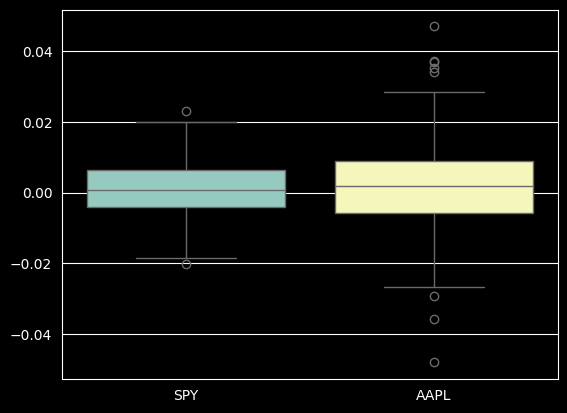

Outliers:
 Ticker          AAPL       SPY
Date                          
2023-05-05  0.046927  0.018513
2023-08-04 -0.048020 -0.004523


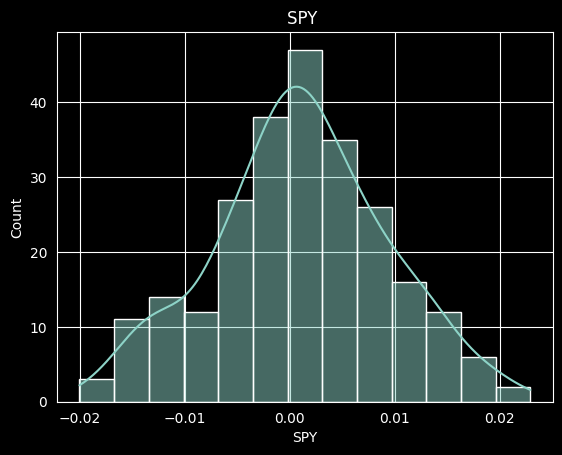

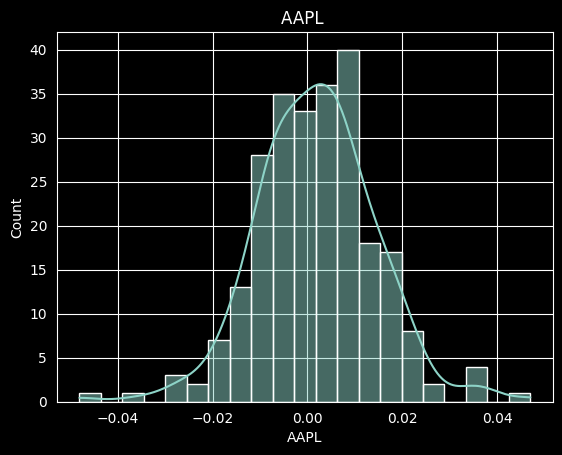

In [71]:
# Outlier Check
sns.boxplot(data = [x,y])
plt.xticks([0,1],['SPY','AAPL'])
plt.show()

# outlier check
from scipy.stats import zscore

# Convert to pandas Series with index alignment
z_x = pd.Series(zscore(x), index=x.index)
z_y = pd.Series(zscore(y), index=y.index)

# Outlier condition
outliers = (z_x.abs() > 3) | (z_y.abs() > 3)

# Apply filter correctly
print("Outliers:\n", returns[outliers])
# Data Distribution

sns.histplot(x,kde = True )
plt.title("SPY ")
plt.show()

sns.histplot(y,kde = True )
plt.title("AAPL ")
plt.show()


In [72]:
# Add a constant to X to include the intercept (β₀) in the regression
x = sm.add_constant(x)


# Fit the Ordinary Least Squares (OLS) regression model
model = sm.OLS(y, x).fit()

# Residual
residuals = model.resid
print(residuals)

Date
2023-01-04    0.001046
2023-01-05    0.001244
2023-01-06    0.010737
2023-01-09    0.003967
2023-01-10   -0.004031
                ...   
2023-12-22   -0.008513
2023-12-26   -0.008249
2023-12-27   -0.002226
2023-12-28    0.001062
2023-12-29   -0.002977
Length: 249, dtype: float64


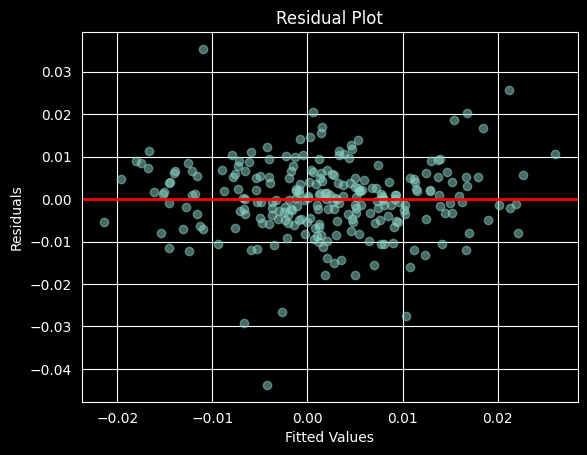

In [73]:
# Residual Plotting

plt.scatter(model.fittedvalues, residuals, alpha=0.5)
plt.axhline(y=0, color='red',linewidth='2')


plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

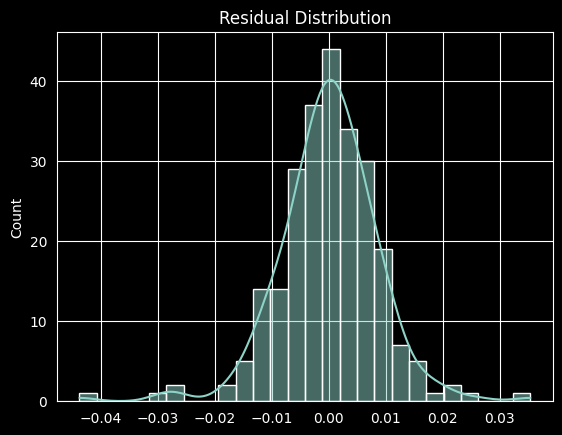

In [74]:
# Residual Distirbution

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

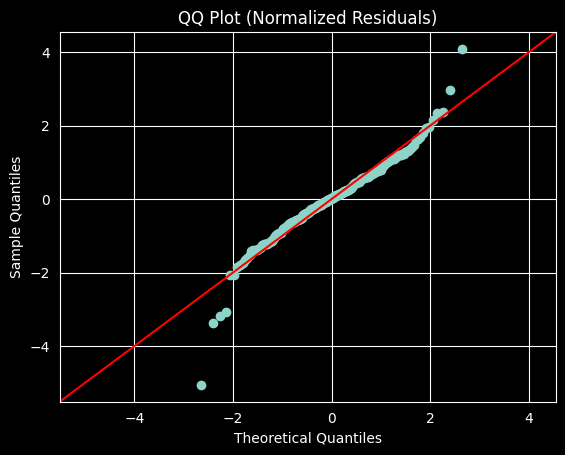

In [75]:
# Normalized  Residual qqplot
sm.qqplot(residuals,fit=True ,line='45')
plt.title("QQ Plot (Normalized Residuals)")
plt.show()

In [76]:
# Print the regression results summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.524
Model:                            OLS   Adj. R-squared:                  0.522
Method:                 Least Squares   F-statistic:                     272.2
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           9.89e-42
Time:                        18:31:34   Log-Likelihood:                 829.42
No. Observations:                 249   AIC:                            -1655.
Df Residuals:                     247   BIC:                            -1648.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.001      1.349      0.1

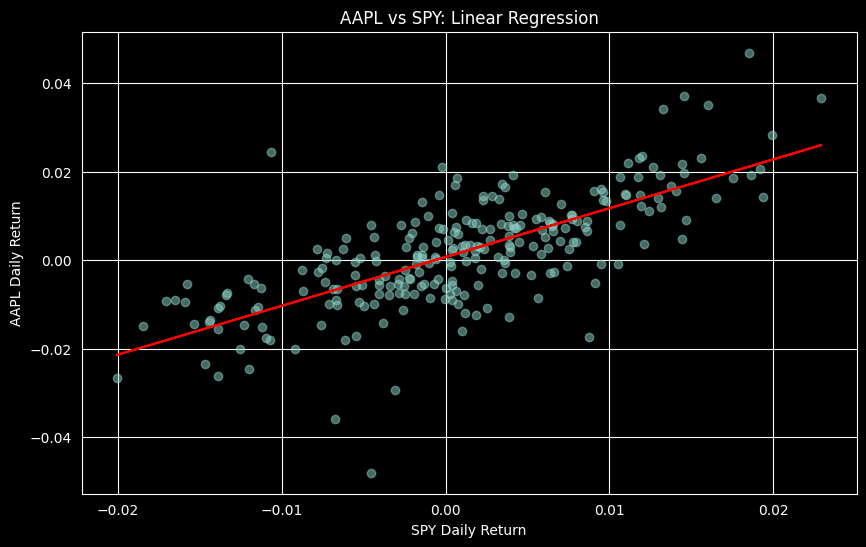

In [77]:
# Plotting the regression line
plt.figure(figsize=(10, 6))  # Set the figure size
# Scatter plot of returns
plt.scatter(returns['SPY'], returns['AAPL'], alpha=0.5)
# Plot the fitted regression line
plt.plot(returns['SPY'], model.predict(x), color='red')

# Set plot title
plt.title("AAPL vs SPY: Linear Regression")
# X-axis label
plt.xlabel("SPY Daily Return")
# Y-axis label
plt.ylabel("AAPL Daily Return")

# Enable grid for readability
plt.grid(True)
# Display the plot
plt.show()

In [78]:
print("Dependent Variable → What we are predicting (Y): Reliance Returns")
print("Independent Variable → What drives prediction (X): NSE Returns")
alpha = model.params.iloc[0]
print(f"Alpha: {alpha} → Extra return when market is 0 (stock-specific return)")
beta = model.params.iloc[1]
print(f"Beta: {beta} → Reliance moves {beta}x of NSE (market sensitivity)")
p_value = model.pvalues.iloc[1]
print(f"P-value: {p_value} → {'Significant (real relationship)' if p_value < 0.05 else 'Not significant (random)'}")
t_stat = model.tvalues.iloc[1]
print(f"T-stat: {t_stat} → Strength of signal (higher = stronger)")
std_err = model.bse.iloc[1]
print(f"Standard Error: {std_err} → Uncertainty in beta (lower = more reliable)")
r2 = model.rsquared
print(f"R²: {r2} → {r2*100:.2f}% of Reliance movement explained by NSE")
adj_r2 = model.rsquared_adj
print(f"Adjusted R²: {adj_r2} → True explanatory power (penalized version)")
f_stat = model.fvalue
print(f"F-statistic: {f_stat} → Overall model usefulness")
f_pval = model.f_pvalue
print(f"F-test p-value: {f_pval} → {'Model is valid' if f_pval < 0.05 else 'Model not useful'}")
mae = np.mean(np.abs(residuals))
print(f"MAE: {mae} → Average prediction error")
rmse = np.sqrt(np.mean(residuals**2))
print(f"RMSE: {rmse} → Typical prediction error (penalizes large errors)")
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print(f"Durbin-Watson: {dw} → {'No autocorrelation' if 1.8 < dw < 2.2 else 'Autocorrelation present'}")
skew = residuals.skew()
print(f"Skewness: {skew} → {'Symmetric distribution' if abs(skew)<0.5 else 'Skewed distribution'}")
kurt = residuals.kurtosis()
print(f"Kurtosis: {kurt} → {'Fat tails (extreme moves likely)' if kurt>3 else 'Normal tails'}")
from scipy.stats import jarque_bera
jb_stat, jb_p = jarque_bera(residuals)

print(f"Jarque-Bera p-value: {jb_p} → {'Normal distribution' if jb_p>0.05 else 'Not normal'}")

Dependent Variable → What we are predicting (Y): Reliance Returns
Independent Variable → What drives prediction (X): NSE Returns
Alpha: 0.0007478235276269983 → Extra return when market is 0 (stock-specific return)
Beta: 1.1036614440162469 → Reliance moves 1.1036614440162469x of NSE (market sensitivity)
P-value: 9.888341794450136e-42 → Significant (real relationship)
T-stat: 16.49933933111639 → Strength of signal (higher = stronger)
Standard Error: 0.0668912507263144 → Uncertainty in beta (lower = more reliable)
R²: 0.5242939409327603 → 52.43% of Reliance movement explained by NSE
Adjusted R²: 0.5223680054709496 → True explanatory power (penalized version)
F-statistic: 272.2281983633243 → Overall model usefulness
F-test p-value: 9.888341794449922e-42 → Model is valid
MAE: 0.006251163323908796 → Average prediction error
RMSE: 0.008652311769486538 → Typical prediction error (penalizes large errors)
Durbin-Watson: 1.7103678053422058 → Autocorrelation present
Skewness: -0.447462154013771 → 